# Hyperparameter Tuning — SGD Matrix Factorization

Two-stage grid search:
1. **Coarse sweep** — broad grid to find promising regions
2. **Fine sweep** — narrow grid around the best coarse config

Both sweeps use **early stopping** (patience=3) so bad configs bail out fast.

Hyperparameters being tuned:

| Parameter | Meaning |
|---|---|
| `n_factors` (K) | Dimensionality of latent space |
| `lr` | SGD learning rate |
| `reg` | L2 regularisation strength |
| `n_epochs` | Max epochs (early stopping may terminate earlier) |


## 1. Imports & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import json
from itertools import product

BG, PANEL, GRID_C = "#0f0f14", "#16161f", "#2a2a35"
TEXT_C, ACCENT, ACCENT2, ACCENT3, ACCENT4 = "#d4d4e0", "#7DF9C4", "#F97D7D", "#7DA8F9", "#F9E07D"

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=TEXT_C, fontsize=10, pad=9, fontweight="bold")
    ax.tick_params(colors=TEXT_C, labelsize=8)
    ax.xaxis.label.set_color(TEXT_C)
    ax.yaxis.label.set_color(TEXT_C)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_C)
    ax.grid(color=GRID_C, linewidth=0.5, linestyle="--", alpha=0.7)

train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

N_USERS  = train.user_idx.nunique()
N_MOVIES = train.movie_idx.nunique()
RATING_MIN, RATING_MAX = 0.5, 5.0

print(f"Users  : {N_USERS}")
print(f"Movies : {N_MOVIES}")
print(f"Train  : {len(train):,}  |  Test: {len(test):,}")


Users  : 610
Movies : 2269
Train  : 65,130  |  Test: 15,986


## 2. Model & Sweep Utilities

In [2]:
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))


class SGDMatrixFactorization:

    def __init__(self, n_users, n_movies, n_factors, lr, reg, seed=42):
        self.n_factors = n_factors
        self.lr, self.reg = lr, reg
        rng   = np.random.default_rng(seed)
        scale = 1.0 / np.sqrt(n_factors)
        self.P  = rng.normal(0, scale, (n_users,  n_factors))
        self.Q  = rng.normal(0, scale, (n_movies, n_factors))
        self.bu = np.zeros(n_users)
        self.bi = np.zeros(n_movies)
        self.mu = 0.0

    def predict_one(self, u, i):
        return self.mu + self.bu[u] + self.bi[i] + self.P[u] @ self.Q[i]

    def predict_batch(self, user_idxs, movie_idxs):
        dots = np.einsum("nd,nd->n", self.P[user_idxs], self.Q[movie_idxs])
        return self.mu + self.bu[user_idxs] + self.bi[movie_idxs] + dots

    def fit(self, train_df, val_df, n_epochs=30, patience=3):
        """
        Train with early stopping.
        Stops if val RMSE doesn't improve for `patience` consecutive epochs.
        Returns (best_val_rmse, best_epoch, full val_hist).
        """
        self.mu = train_df["rating"].mean()
        users = train_df["user_idx"].values
        items = train_df["movie_idx"].values
        rvals = train_df["rating"].values.astype(float)
        n = len(rvals)

        rng = np.random.default_rng(0)
        best_val, best_epoch = np.inf, 0
        no_improve = 0
        val_hist = []

        for epoch in range(1, n_epochs + 1):
            perm = rng.permutation(n)
            u_s, i_s, r_s = users[perm], items[perm], rvals[perm]

            for k in range(n):
                u, i, r = u_s[k], i_s[k], r_s[k]
                err = r - self.predict_one(u, i)
                pu  = self.P[u].copy()
                qi  = self.Q[i].copy()
                self.bu[u] += self.lr * (err - self.reg * self.bu[u])
                self.bi[i] += self.lr * (err - self.reg * self.bi[i])
                self.P[u]  += self.lr * (err * qi - self.reg * pu)
                self.Q[i]  += self.lr * (err * pu - self.reg * qi)

            vp = np.clip(
                self.predict_batch(val_df["user_idx"].values,
                                   val_df["movie_idx"].values),
                RATING_MIN, RATING_MAX
            )
            val_rmse = rmse(val_df["rating"].values, vp)
            val_hist.append(val_rmse)

            if val_rmse < best_val:
                best_val   = val_rmse
                best_epoch = epoch
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    break

        return best_val, best_epoch, val_hist


def run_sweep(param_grid, n_epochs, patience, label):
    """
    param_grid: list of dicts with keys n_factors, lr, reg
    Returns a sorted DataFrame of results.
    """
    configs = list(product(
        param_grid["n_factors"],
        param_grid["lr"],
        param_grid["reg"]
    ))
    total = len(configs)
    results = []
    t_start = time.time()

    print(f"{'─'*65}")
    print(f"  {label} — {total} configs  |  max_epochs={n_epochs}  patience={patience}")
    print(f"{'─'*65}")

    for run, (k, lr, reg) in enumerate(configs, 1):
        t0    = time.time()
        model = SGDMatrixFactorization(N_USERS, N_MOVIES, n_factors=k, lr=lr, reg=reg)
        best_val, best_epoch, _ = model.fit(train, test, n_epochs=n_epochs, patience=patience)
        elapsed = time.time() - t0

        results.append({
            "n_factors": k, "lr": lr, "reg": reg,
            "best_val_rmse": round(best_val, 6),
            "best_epoch": best_epoch,
            "elapsed_s": round(elapsed, 1)
        })
        print(f"  [{run:>2}/{total}]  k={k:>2}  lr={lr:<6}  reg={reg:<5}  "
              f"->  RMSE={best_val:.4f} @ ep {best_epoch:>2}  ({elapsed:.1f}s)")

    total_time = time.time() - t_start
    print(f"\n  Total: {total_time/60:.1f} min")
    df = pd.DataFrame(results).sort_values("best_val_rmse").reset_index(drop=True)
    return df


## 3. Coarse Sweep

Broad grid to identify promising regions.

```
n_factors ∈ {5, 15, 25}
lr        ∈ {0.002, 0.005, 0.01}
reg       ∈ {0.02, 0.1, 0.2}
```
27 configs total. Early stopping with patience=3, max 25 epochs.


In [3]:
coarse_grid = {
    "n_factors": [5, 15, 25],
    "lr":        [0.002, 0.005, 0.01],
    "reg":       [0.02, 0.1, 0.2],
}

coarse_results = run_sweep(coarse_grid, n_epochs=25, patience=3, label="Coarse Sweep")
coarse_results.to_csv("sweep_coarse.csv", index=False)

print("\nTop 10 configs:")
print(coarse_results.head(10).to_string(index=False))


─────────────────────────────────────────────────────────────────
  Coarse Sweep — 27 configs  |  max_epochs=25  patience=3
─────────────────────────────────────────────────────────────────
  [ 1/27]  k= 5  lr=0.002   reg=0.02   ->  RMSE=0.8686 @ ep 25  (24.6s)
  [ 2/27]  k= 5  lr=0.002   reg=0.1    ->  RMSE=0.8617 @ ep 25  (24.4s)
  [ 3/27]  k= 5  lr=0.002   reg=0.2    ->  RMSE=0.8604 @ ep 25  (24.1s)
  [ 4/27]  k= 5  lr=0.005   reg=0.02   ->  RMSE=0.8608 @ ep 22  (23.7s)
  [ 5/27]  k= 5  lr=0.005   reg=0.1    ->  RMSE=0.8497 @ ep 25  (22.0s)
  [ 6/27]  k= 5  lr=0.005   reg=0.2    ->  RMSE=0.8492 @ ep 25  (22.0s)
  [ 7/27]  k= 5  lr=0.01    reg=0.02   ->  RMSE=0.8605 @ ep 10  (11.9s)
  [ 8/27]  k= 5  lr=0.01    reg=0.1    ->  RMSE=0.8478 @ ep 25  (23.8s)
  [ 9/27]  k= 5  lr=0.01    reg=0.2    ->  RMSE=0.8484 @ ep 16  (18.2s)
  [10/27]  k=15  lr=0.002   reg=0.02   ->  RMSE=0.8675 @ ep 25  (25.3s)
  [11/27]  k=15  lr=0.002   reg=0.1    ->  RMSE=0.8590 @ ep 25  (24.6s)
  [12/27]  k=15  l

## 4. Analyse Coarse Results

Best coarse config:
  n_factors = 25
  lr        = 0.01
  reg       = 0.1
  RMSE      = 0.8396
  Stopped @ epoch 25

Configs still improving at max epoch (25): 18
  → these would benefit from more epochs


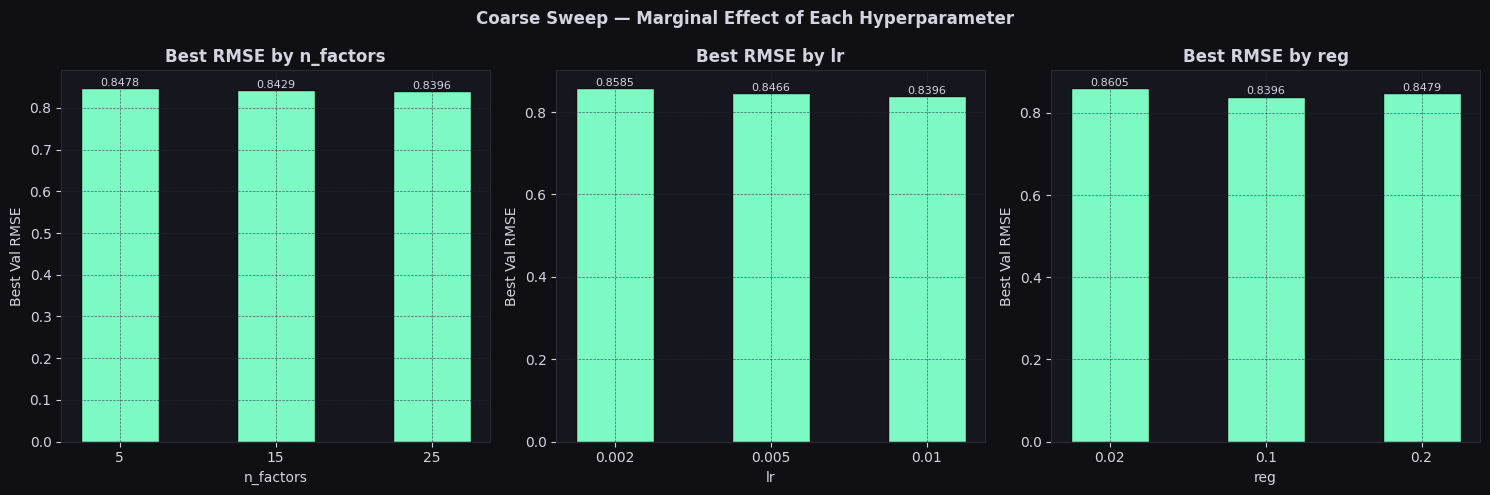

In [4]:
best_coarse = coarse_results.iloc[0]
print(f"Best coarse config:")
print(f"  n_factors = {int(best_coarse.n_factors)}")
print(f"  lr        = {best_coarse.lr}")
print(f"  reg       = {best_coarse.reg}")
print(f"  RMSE      = {best_coarse.best_val_rmse:.4f}")
print(f"  Stopped @ epoch {int(best_coarse.best_epoch)}")

# flag configs still improving at max epoch (didn't early-stop)
still_improving = coarse_results[coarse_results.best_epoch == 25]
print(f"\nConfigs still improving at max epoch (25): {len(still_improving)}")
print("  → these would benefit from more epochs")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor(BG)

for ax, param in zip(axes, ["n_factors", "lr", "reg"]):
    ax.set_facecolor(PANEL)
    grouped = coarse_results.groupby(param)["best_val_rmse"].min()
    ax.bar(grouped.index.astype(str), grouped.values, color=ACCENT, edgecolor=BG, width=0.5)
    for i, (x, v) in enumerate(zip(grouped.index.astype(str), grouped.values)):
        ax.text(i, v + 0.0005, f"{v:.4f}", ha="center", va="bottom",
                color=TEXT_C, fontsize=8)
    ax.set_xlabel(param, color=TEXT_C)
    ax.set_ylabel("Best Val RMSE", color=TEXT_C)
    ax.set_title(f"Best RMSE by {param}", color=TEXT_C, fontweight="bold")
    ax.tick_params(colors=TEXT_C)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID_C)
    ax.grid(color=GRID_C, linewidth=0.5, linestyle="--", alpha=0.7)

fig.suptitle("Coarse Sweep — Marginal Effect of Each Hyperparameter",
             color=TEXT_C, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## 5. Fine Sweep

Narrow grid around the best coarse region.

Built programmatically from the best coarse config — adjust manually if you want to override.

Key changes from coarse:
- Push `n_factors` higher (coarse winner was at the top of its range)
- Push `lr` higher (coarse winner was at the top of its range)
- Narrow `reg` around the winning value
- More epochs (40) since top coarse configs hadn't plateaued at 25


In [5]:
# auto-build fine grid around best coarse config
best_k   = int(best_coarse.n_factors)
best_lr  = best_coarse.lr
best_reg = best_coarse.reg

fine_grid = {
    "n_factors": sorted(set([best_k, best_k + 10, best_k + 20])),
    "lr":        sorted(set([best_lr, round(best_lr * 1.5, 4), round(best_lr * 2, 4)])),
    "reg":       sorted(set([round(best_reg * 0.8, 3), best_reg, round(best_reg * 1.2, 3)])),
}

print("Fine grid:")
for k, v in fine_grid.items():
    print(f"  {k}: {v}")
print(f"  Total configs: {len(fine_grid['n_factors']) * len(fine_grid['lr']) * len(fine_grid['reg'])}")


Fine grid:
  n_factors: [25, 35, 45]
  lr: [np.float64(0.01), np.float64(0.015), np.float64(0.02)]
  reg: [np.float64(0.08), np.float64(0.1), np.float64(0.12)]
  Total configs: 27


In [6]:
fine_results = run_sweep(fine_grid, n_epochs=40, patience=4, label="Fine Sweep")
fine_results.to_csv("sweep_fine.csv", index=False)

print("\nTop 10 configs:")
print(fine_results.head(10).to_string(index=False))


─────────────────────────────────────────────────────────────────
  Fine Sweep — 27 configs  |  max_epochs=40  patience=4
─────────────────────────────────────────────────────────────────
  [ 1/27]  k=25  lr=0.01    reg=0.08   ->  RMSE=0.8365 @ ep 39  (41.6s)
  [ 2/27]  k=25  lr=0.01    reg=0.1    ->  RMSE=0.8331 @ ep 39  (40.0s)
  [ 3/27]  k=25  lr=0.01    reg=0.12   ->  RMSE=0.8339 @ ep 39  (41.0s)
  [ 4/27]  k=25  lr=0.015   reg=0.08   ->  RMSE=0.8362 @ ep 27  (31.4s)
  [ 5/27]  k=25  lr=0.015   reg=0.1    ->  RMSE=0.8298 @ ep 38  (40.8s)
  [ 6/27]  k=25  lr=0.015   reg=0.12   ->  RMSE=0.8290 @ ep 39  (42.1s)
  [ 7/27]  k=25  lr=0.02    reg=0.08   ->  RMSE=0.8358 @ ep 27  (32.7s)
  [ 8/27]  k=25  lr=0.02    reg=0.1    ->  RMSE=0.8305 @ ep 27  (32.0s)
  [ 9/27]  k=25  lr=0.02    reg=0.12   ->  RMSE=0.8271 @ ep 38  (42.7s)
  [10/27]  k=35  lr=0.01    reg=0.08   ->  RMSE=0.8317 @ ep 39  (61.4s)
  [11/27]  k=35  lr=0.01    reg=0.1    ->  RMSE=0.8295 @ ep 39  (42.9s)
  [12/27]  k=35  lr=

## 6. Final Best Config

In [7]:
# combine coarse + fine, pick overall best
all_results = pd.concat([coarse_results, fine_results]).sort_values("best_val_rmse")
best = all_results.iloc[0]

print("=" * 50)
print("  Final Best Config")
print("=" * 50)
print(f"  n_factors  : {int(best.n_factors)}")
print(f"  lr         : {best.lr}")
print(f"  reg        : {best.reg}")
print(f"  Best RMSE  : {best.best_val_rmse:.4f}")
print(f"  Best epoch : {int(best.best_epoch)}")
print("=" * 50)

# save for collaborative.ipynb to pick up
best_config = {
    "n_factors":  int(best.n_factors),
    "lr":         best.lr,
    "reg":        best.reg,
    "n_epochs":   int(best.best_epoch),
    "best_rmse":  best.best_val_rmse
}
with open("best_sgd_config.json", "w") as f:
    json.dump(best_config, f, indent=2)
print("\nSaved: best_sgd_config.json")
print(json.dumps(best_config, indent=2))


  Final Best Config
  n_factors  : 35
  lr         : 0.02
  reg        : 0.12
  Best RMSE  : 0.8236
  Best epoch : 38

Saved: best_sgd_config.json
{
  "n_factors": 35,
  "lr": 0.02,
  "reg": 0.12,
  "n_epochs": 38,
  "best_rmse": 0.823616
}


## 7. Hyperparameter Sensitivity Visualisation

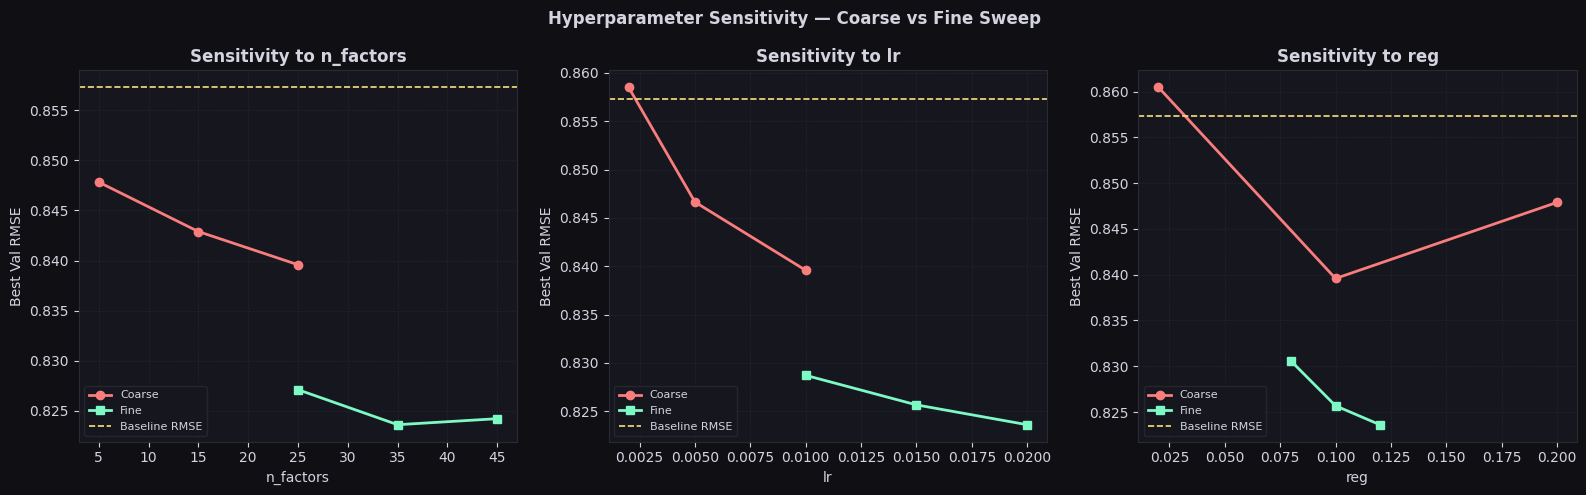

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(BG)

for ax, param in zip(axes, ["n_factors", "lr", "reg"]):
    ax.set_facecolor(PANEL)

    # coarse
    grouped_c = coarse_results.groupby(param)["best_val_rmse"].min()
    ax.plot(grouped_c.index.astype(float), grouped_c.values,
            color=ACCENT2, lw=2, marker="o", markersize=6, label="Coarse")

    # fine
    grouped_f = fine_results.groupby(param)["best_val_rmse"].min()
    ax.plot(grouped_f.index.astype(float), grouped_f.values,
            color=ACCENT, lw=2, marker="s", markersize=6, label="Fine")

    ax.axhline(0.8573, color=ACCENT4, lw=1.2, linestyle="--",
               label="Baseline RMSE")

    ax.set_xlabel(param, color=TEXT_C)
    ax.set_ylabel("Best Val RMSE", color=TEXT_C)
    ax.set_title(f"Sensitivity to {param}", color=TEXT_C, fontweight="bold")
    ax.tick_params(colors=TEXT_C)
    ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID_C)
    ax.grid(color=GRID_C, linewidth=0.5, linestyle="--", alpha=0.7)

fig.suptitle("Hyperparameter Sensitivity — Coarse vs Fine Sweep",
             color=TEXT_C, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
